In [1]:
!pip install pandas

In [2]:
import pandas as pd
papers56 = pd.read_csv('data/raw/cogsci_1956-1990.csv')
print(papers56.shape[0])
#notna = papers56["abstract"].dropna()
papers56.info()
papers56.head(20)

1152
<class 'pandas.DataFrame'>
RangeIndex: 1152 entries, 0 to 1151
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     1152 non-null   str    
 1   abstract                               71 non-null     str    
 2   authorships.author.display_name        1086 non-null   str    
 3   authorships.author.id                  1085 non-null   str    
 4   authorships.author.orcid               547 non-null    str    
 5   authorships.countries                  695 non-null    str    
 6   authorships.institutions.display_name  537 non-null    str    
 7   authorships.institutions.id            537 non-null    str    
 8   authorships.is_corresponding           1086 non-null   str    
 9   best_oa_location.license               16 non-null     str    
 10  citation_normalized_percentile.value   1122 non-null   float64
 11  cited_by_c

,id,abstract,authorships.author.display_name,authorships.author.id,authorships.author.orcid,authorships.countries,authorships.institutions.display_name,authorships.institutions.id,authorships.is_corresponding,best_oa_location.license,...,open_access.is_oa,open_access.oa_status,primary_location.source.display_name,primary_location.source.id,primary_location.source.issn_l,primary_location.source.type,primary_topic.display_name,publication_date,publication_year,type
0,https://openalex.org/W2032152873,NaN,Marilyn Ford,https://openalex.org/A5032395113,NaN,NaN,NaN,NaN,True,NaN,...,False,closed,Language,https://openalex.org/S176347361,0097-8507,journal,"Language, Metaphor, and Cognition",1985-12-01,1985,article
1,https://openalex.org/W1601488840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,closed,The MIT Press eBooks,https://openalex.org/S4306463997,NaN,ebook platform,Cognitive Science and Mapping,1989-11-21,1989,book
2,https://openalex.org/W2085317013,NaN,Zenon W. Pylyshyn,https://openalex.org/A5112745042,NaN,CA,Western University,https://openalex.org/I125749732,True,NaN,...,False,closed,Artificial Intelligence,https://openalex.org/S196139623,0004-3702,journal,Neural Networks and Applications,1989-03-01,1989,article
3,https://openalex.org/W1508363014,NaN,Daniel G. Bobrow|Alan Collins,https://openalex.org/A5051959560|https://opena...,|https://orcid.org/0000-0001-9805-9091,|,NaN,NaN,True|False,NaN,...,False,closed,NaN,NaN,NaN,NaN,Cognitive Science and Mapping,1975-01-01,1975,book
4,https://openalex.org/W2140850270,NaN,Zenon W. Pylyshyn,https://openalex.org/A5112745042,NaN,NaN,NaN,NaN,True,NaN,...,False,closed,Behavioral and Brain Sciences,https://openalex.org/S59628311,0140-525X,journal,"Computability, Logic, AI Algorithms",1980-03-01,1980,article
5,https://openalex.org/W1528211185,NaN,P. N. Johnson‐Laird|P. C. Wason,https://openalex.org/A5032136375|https://opena...,https://orcid.org/0000-0003-4461-1324|,|,NaN,NaN,True|False,NaN,...,False,closed,NaN,NaN,NaN,NaN,Cognitive Science and Mapping,1977-01-01,1977,book
6,https://openalex.org/W2159957987,NaN,P. N. Johnson‐Laird,https://openalex.org/A5032136375,https://orcid.org/0000-0003-4461-1324,GB,University of Sussex,https://openalex.org/I162608824,True,NaN,...,False,closed,Cognitive Science,https://openalex.org/S78735424,0364-0213,journal,Child and Animal Learning Development,1980-01-01,1980,article
7,https://openalex.org/W118790152,NaN,Stephen P. Stich,https://openalex.org/A5104929530,NaN,NaN,NaN,NaN,True,NaN,...,False,closed,NaN,NaN,NaN,NaN,Cognitive Science and Education Research,1983-01-01,1983,book
8,https://openalex.org/W345850181,NaN,Hubert L. Dreyfus|Harrison Hall,https://openalex.org/A5109001069|https://opena...,|,|,NaN,NaN,True|False,NaN,...,False,closed,NaN,NaN,NaN,NaN,Phenomenology and Existential Philosophy,1982-01-01,1982,book
9,https://openalex.org/W1760205449,NaN,Neil Stillings|Mark Feinstein|Jay L. Garfield|...,https://openalex.org/A5033109823|https://opena...,||||https://orcid.org/0000-0003-0103-7676||htt...,US|US|US|US|US|US|US,Hampshire College|Hampshire College|Hampshire ...,https://openalex.org/I47631775|https://openale...,True|False|False|False|False|False|False,NaN,...,False,closed,NaN,NaN,NaN,NaN,Cognitive Science and Mapping,1987-05-01,1987,book


In [3]:
from sentence_transformers import SentenceTransformer

# Load model - automatically uses GPU if PyTorch CUDA is available
model = SentenceTransformer("all-mpnet-base-v2")

# Verify GPU is being used
print(model.device)  # Should print: cuda:0

c:\Users\milos\miniconda3\envs\magisterka\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda:0


In [27]:
def encode_paper(paper):
    abstract = paper["abstract"]
    if pd.isna(abstract):
        return None  # Skip papers without abstracts
    embedding = model.encode(abstract)
    return embedding

papers56["embedding"] = papers56.apply(encode_paper, axis=1)


In [28]:
embedded56 = papers56[~papers56["embedding"].isna()]
embedded56

,id,abstract,authorships.author.display_name,authorships.author.id,authorships.author.orcid,authorships.countries,authorships.institutions.display_name,authorships.institutions.id,authorships.is_corresponding,best_oa_location.license,...,open_access.oa_status,primary_location.source.display_name,primary_location.source.id,primary_location.source.issn_l,primary_location.source.type,primary_topic.display_name,publication_date,publication_year,type,embedding
19,https://openalex.org/W2002170215,"Cognitive science is, of course, not really a ...",Herbert A. Simon,https://openalex.org/A5108357701,NaN,US,Carnegie Mellon University,https://openalex.org/I74973139,True,NaN,...,bronze,Cognitive Science,https://openalex.org/S78735424,0364-0213,journal,Cognitive Science and Mapping,1980-01-01,1980,article,"[-0.0034810635, 0.03295613, -0.0476671, -0.068..."
41,https://openalex.org/W1978993273,Research in schizophrenia illustrates that the...,Michael E. Dawson,https://openalex.org/A5110898452,NaN,US,University of Southern California|Southern Cal...,https://openalex.org/I1174212|https://openalex...,True,NaN,...,bronze,Psychophysiology,https://openalex.org/S167723465,0048-5772,journal,Mental Health Research Topics,1990-05-01,1990,review,"[-0.028923748, 0.01782563, 0.004583388, 0.0100..."
53,https://openalex.org/W2130308430,A resource-realistic perspective suggests some...,Christopher Cherniak,https://openalex.org/A5024627342,https://orcid.org/0000-0002-5244-096X,US,"University of Maryland, College Park",https://openalex.org/I66946132,True,NaN,...,bronze,Communications of the ACM,https://openalex.org/S103482838,0001-0782,journal,"Computability, Logic, AI Algorithms",1988-04-01,1988,article,"[0.031051766, 0.071332656, -0.04477581, -0.003..."
77,https://openalex.org/W1979007755,The issues raised by the anti-individualist ar...,Tyler Burge,https://openalex.org/A5080738380,NaN,NaN,NaN,NaN,True,NaN,...,bronze,Notre Dame Journal of Formal Logic,https://openalex.org/S78544662,0029-4527,journal,Space Science and Extraterrestrial Life,1982-07-01,1982,article,"[0.038878836, 0.07049363, -0.033074133, 0.0412..."
82,https://openalex.org/W10672028,"The effects of cholesterol, 7-dehydrocholester...",Bertram C. Bruce,https://openalex.org/A5090063447,https://orcid.org/0000-0001-7392-6945,NaN,NaN,NaN,True,NaN,...,green,European Journal of Biochemistry,https://openalex.org/S4210214924,0014-2956,journal,Advanced Text Analysis Techniques,1978-01-01,1978,article,"[0.033137657, -0.027978117, 0.048303958, 0.005..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,https://openalex.org/W658854855,Issues in Cognitive Psychology and Instruction...,Ronna F. Dillon|Robert J. Sternberg,https://openalex.org/A5020161298|https://opena...,|https://orcid.org/0000-0001-7191-5169,|,NaN,NaN,True|False,cc-by-sa,...,green,NaN,NaN,NaN,NaN,Education and Critical Thinking Development,1986-01-01,1986,book,"[0.009219816, 0.0020467811, -0.03074522, -0.01..."
1101,https://openalex.org/W2271733756,This paper is a review of the state of the art...,Claude M. J. Braun|Marc Andre Ethier|Jacinthe ...,https://openalex.org/A5108528121|https://opena...,||,CA|CA|CA,Université du Québec à Montréal|Concordia Univ...,https://openalex.org/I159129438|https://openal...,True|False|False,NaN,...,bronze,Canadian Journal of Community Mental Health,https://openalex.org/S2764469303,0713-3936,journal,Stroke Rehabilitation and Recovery,1990-09-01,1990,article,"[0.02708221, -0.024101304, -0.029811507, -0.00..."
1103,https://openalex.org/W1992237649,The Yale Al Project is an interdisciplinary re...,Natalie Dehn,https://openalex.org/A5087585549,NaN,US,Yale University,https://openalex.org/I32971472,True,NaN,...,bronze,ACM SIGART Bulletin,https://openalex.org/S4210224649,0163-5719,journal,Natural Language Processing Techniques,1982-01-01,1982,article,"[0.039852362, 0.045867193, -0.045085173, 0.021..."
1115,https://openalex.org/W293393595,This thesis takes as its initial Premis

In [29]:
embedded56.reset_index(drop=True, inplace=True)
embedded56


,id,abstract,authorships.author.display_name,authorships.author.id,authorships.author.orcid,authorships.countries,authorships.institutions.display_name,authorships.institutions.id,authorships.is_corresponding,best_oa_location.license,...,open_access.oa_status,primary_location.source.display_name,primary_location.source.id,primary_location.source.issn_l,primary_location.source.type,primary_topic.display_name,publication_date,publication_year,type,embedding
0,https://openalex.org/W2002170215,"Cognitive science is, of course, not really a ...",Herbert A. Simon,https://openalex.org/A5108357701,NaN,US,Carnegie Mellon University,https://openalex.org/I74973139,True,NaN,...,bronze,Cognitive Science,https://openalex.org/S78735424,0364-0213,journal,Cognitive Science and Mapping,1980-01-01,1980,article,"[-0.0034810635, 0.03295613, -0.0476671, -0.068..."
1,https://openalex.org/W1978993273,Research in schizophrenia illustrates that the...,Michael E. Dawson,https://openalex.org/A5110898452,NaN,US,University of Southern California|Southern Cal...,https://openalex.org/I1174212|https://openalex...,True,NaN,...,bronze,Psychophysiology,https://openalex.org/S167723465,0048-5772,journal,Mental Health Research Topics,1990-05-01,1990,review,"[-0.028923748, 0.01782563, 0.004583388, 0.0100..."
2,https://openalex.org/W2130308430,A resource-realistic perspective suggests some...,Christopher Cherniak,https://openalex.org/A5024627342,https://orcid.org/0000-0002-5244-096X,US,"University of Maryland, College Park",https://openalex.org/I66946132,True,NaN,...,bronze,Communications of the ACM,https://openalex.org/S103482838,0001-0782,journal,"Computability, Logic, AI Algorithms",1988-04-01,1988,article,"[0.031051766, 0.071332656, -0.04477581, -0.003..."
3,https://openalex.org/W1979007755,The issues raised by the anti-individualist ar...,Tyler Burge,https://openalex.org/A5080738380,NaN,NaN,NaN,NaN,True,NaN,...,bronze,Notre Dame Journal of Formal Logic,https://openalex.org/S78544662,0029-4527,journal,Space Science and Extraterrestrial Life,1982-07-01,1982,article,"[0.038878836, 0.07049363, -0.033074133, 0.0412..."
4,https://openalex.org/W10672028,"The effects of cholesterol, 7-dehydrocholester...",Bertram C. Bruce,https://openalex.org/A5090063447,https://orcid.org/0000-0001-7392-6945,NaN,NaN,NaN,True,NaN,...,green,European Journal of Biochemistry,https://openalex.org/S4210214924,0014-2956,journal,Advanced Text Analysis Techniques,1978-01-01,1978,article,"[0.033137657, -0.027978117, 0.048303958, 0.005..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,https://openalex.org/W658854855,Issues in Cognitive Psychology and Instruction...,Ronna F. Dillon|Robert J. Sternberg,https://openalex.org/A5020161298|https://opena...,|https://orcid.org/0000-0001-7191-5169,|,NaN,NaN,True|False,cc-by-sa,...,green,NaN,NaN,NaN,NaN,Education and Critical Thinking Development,1986-01-01,1986,book,"[0.009219816, 0.0020467811, -0.03074522, -0.01..."
67,https://openalex.org/W2271733756,This paper is a review of the state of the art...,Claude M. J. Braun|Marc Andre Ethier|Jacinthe ...,https://openalex.org/A5108528121|https://opena...,||,CA|CA|CA,Université du Québec à Montréal|Concordia Univ...,https://openalex.org/I159129438|https://openal...,True|False|False,NaN,...,bronze,Canadian Journal of Community Mental Health,https://openalex.org/S2764469303,0713-3936,journal,Stroke Rehabilitation and Recovery,1990-09-01,1990,article,"[0.02708221, -0.024101304, -0.029811507, -0.00..."
68,https://openalex.org/W1992237649,The Yale Al Project is an interdisciplinary re...,Natalie Dehn,https://openalex.org/A5087585549,NaN,US,Yale University,https://openalex.org/I32971472,True,NaN,...,bronze,ACM SIGART Bulletin,https://openalex.org/S4210224649,0163-5719,journal,Natural Language Processing Techniques,1982-01-01,1982,article,"[0.039852362, 0.045867193, -0.045085173, 0.021..."
69,https://openalex.org/W293393595,This thesis takes as its initial Premise the i...,Ia

In [30]:
#!pip install pacmap

In [31]:
!pip install numpy

In [32]:
import numpy as np
X = np.vstack(embedded56["embedding"].to_numpy()).astype(np.float32)
print(X.shape)

(71, 768)


In [33]:
import pacmap
mapper = pacmap.PaCMAP(random_state=42)
X_2d = mapper.fit_transform(X)

In [34]:
!pip install matplotlib

In [35]:
print(embedded56["primary_topic.display_name"].value_counts())
color_map = {"Cognitive Science and Mapping": "red", "Computability, Logic, AI Algorithms": "orange", "Language, Metaphor, and Cognition": "green"}
color_mask = embedded56["primary_topic.display_name"].map(color_map).fillna("gray")
print(color_mask)

primary_topic.display_name
Cognitive Science and Mapping                         8
Computability, Logic, AI Algorithms                   5
Language, Metaphor, and Cognition                     5
Child and Animal Learning Development                 5
Neural Networks and Applications                      4
Classical Philosophy and Thought                      2
Embodied and Extended Cognition                       2
Cognitive Science and Education Research              2
Syntax, Semantics, Linguistic Variation               2
Natural Language Processing Techniques                2
Neuroscience and Music Perception                     2
Mental Health Research Topics                         1
Space Science and Extraterrestrial Life               1
Advanced Text Analysis Techniques                     1
Linguistics and Discourse Analysis                    1
Bayesian Modeling and Causal Inference                1
Visual perception and processing mechanisms           1
Memory Processes and 

In [37]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

# Choose a cluster count that best separates the 2D PaCMAP points.
k_values = range(4, 13)
silhouette_scores = {}

for k in k_values:
    model_k = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels_k = model_k.fit_predict(X_2d)
    silhouette_scores[k] = silhouette_score(X_2d, labels_k)

best_k = max(silhouette_scores, key=silhouette_scores.get)
print("Silhouette by k:", silhouette_scores)
print("Best k:", best_k)

kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=42)
embedded56 = embedded56.copy()
embedded56["cluster"] = kmeans.fit_predict(X_2d)
embedded56["pacmap_x"] = X_2d[:, 0]
embedded56["pacmap_y"] = X_2d[:, 1]

# Build short topic labels for each cluster using top TF-IDF terms from abstracts.
texts = embedded56["abstract"].fillna("")
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000, min_df=3)
tfidf = vectorizer.fit_transform(texts)
terms = np.array(vectorizer.get_feature_names_out())

cluster_topic_labels = {}
for cluster_id in sorted(embedded56["cluster"].unique()):
    idx = np.where(embedded56["cluster"].to_numpy() == cluster_id)[0]
    mean_tfidf = tfidf[idx].mean(axis=0).A1
    top_terms = terms[np.argsort(mean_tfidf)[-5:]][::-1]
    cluster_topic_labels[cluster_id] = ", ".join(top_terms[:3])

print("Cluster sizes:")
print(embedded56["cluster"].value_counts().sort_index())
print("\nCluster topic labels:")
for cid in sorted(cluster_topic_labels):
    print(f"{cid}: {cluster_topic_labels[cid]}")

Silhouette by k: {4: 0.5191648006439209, 5: 0.45374518632888794, 6: 0.4305230677127838, 7: 0.44086530804634094, 8: 0.42940372228622437, 9: 0.4078884422779083, 10: 0.43836143612861633, 11: 0.4464033544063568, 12: 0.4504939019680023}
Best k: 4
Cluster sizes:
cluster
0    23
1    12
2    14
3    22
Name: count, dtype: int64

Cluster topic labels:
0: cognitive, models, science
1: available, writing, abstract
2: research, linguistic, language
3: cognitive, piaget, psychology


c:\Users\milos\miniconda3\envs\magisterka\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\milos\miniconda3\envs\magisterka\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\milos\miniconda3\envs\magisterka\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Wi

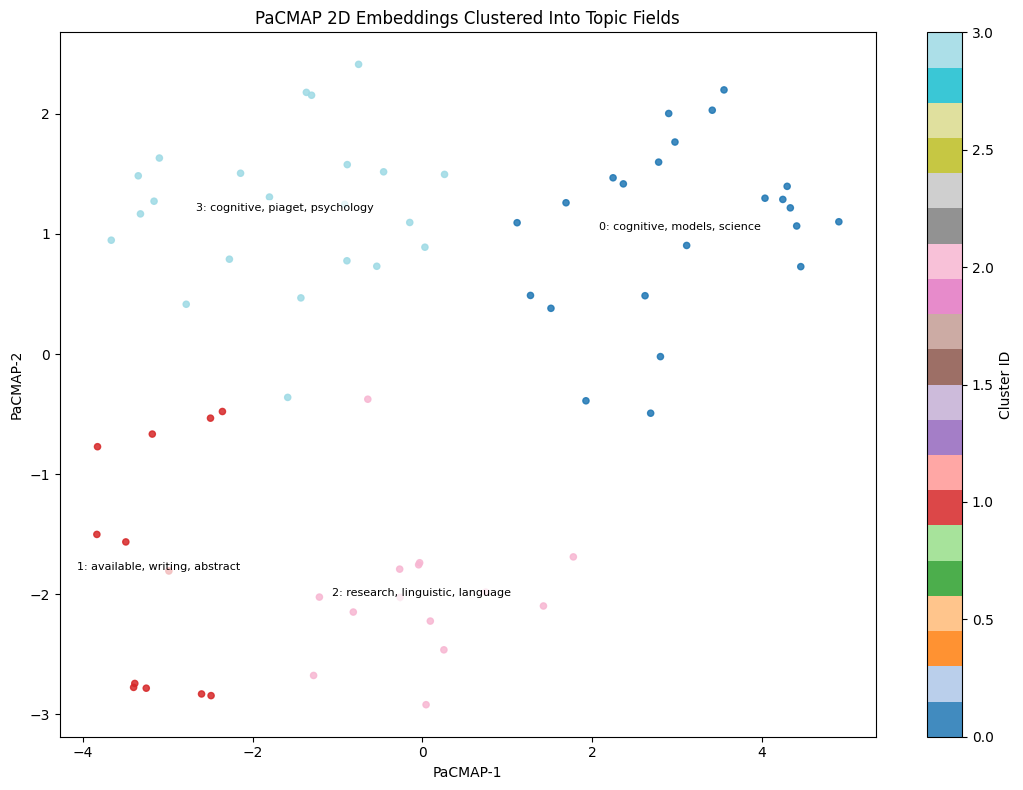

In [38]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    embedded56["pacmap_x"],
    embedded56["pacmap_y"],
    c=embedded56["cluster"],
    cmap="tab20",
    s=20,
    alpha=0.85,
)

for cluster_id in sorted(embedded56["cluster"].unique()):
    points = embedded56.loc[embedded56["cluster"] == cluster_id, ["pacmap_x", "pacmap_y"]]
    cx, cy = points.mean(axis=0)
    label = cluster_topic_labels.get(cluster_id, f"cluster {cluster_id}")
    ax.text(
        cx,
        cy,
        f"{cluster_id}: {label}",
        fontsize=8,
        ha="center",
        va="center",
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "pad": 2},
    )

ax.set_title("PaCMAP 2D Embeddings Clustered Into Topic Fields")
ax.set_xlabel("PaCMAP-1")
ax.set_ylabel("PaCMAP-2")
fig.colorbar(scatter, ax=ax, label="Cluster ID")
plt.tight_layout()
plt.show()